We created the sample data from the full public labeled datset like this:

```python
# specify location of labeled dataset
labels_dir = "./localization_dataset_labeled_clips"

# read in the csv of audio clip annotations
labels = pd.read_csv(f"{labels_dir}/labeled_clips.csv")

# sample 10 songs of 10 individuals for sample data in repo
label_subset = pd.concat([
    labels[labels.aiid_label==c].sample(10, random_state=2024)
    for c in range(1,11)
])
len(label_subset)
label_subset['song_center_time']=5
label_subset.drop(columns={
    "nearest_recorder", "aiid_label_sl", "notes_sl", "aiid_label_cc", "notes_cc", "rel_path", "folder"
}).to_csv("./sample_data/labeled_clips_sample.csv", index=False)

import os
dir="./sample_data"
for f in label_subset.rel_path:
    # copy files to local folder
    os.system(f"cp {labels_dir}/{f} {dir}/")
```

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.autonotebook import tqdm
import opensoundscape as opso
import tuftelike

from matplotlib import pyplot as plt
def figsize(w,h):
    plt.rcParams['figure.figsize']=[w,h]
figsize(15,5) #for big visuals
%config InlineBackend.figure_format = 'retina'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# gill sans
plt.rcParams['font.family'] = 'Gill Sans'

import torch
def identity(x):
    return x

# local source code imports
import sys
sys.path.append(f'./src/')
import evaluation
from evaluation import evaluate, mean_range_table
from preprocessor import OvenbirdPreprocessor
import random
from model import Resnet18_Classifier, ContrastiveResnet18

palette = sns.color_palette("deep") + sns.color_palette("Dark2")

# set seed for reproducibility
random.seed(2024)
np.random.seed(2024)
metrics_list = ["accuracy", "ari", "nmi", "fmi", "v_measure"]

import seaborn as sns

## sample data of individual Ovenbird songs

In [40]:
audio_clip_table = pd.read_csv('./sample_data/labeled_clips_sample.csv')

## Generate or load test set embeddings with each model

In [42]:
# load the trained Ovenbird feature extractor model, using GPU device if one is available
ckpt_path = (
    "./checkpoints/full_2025-04-10T11:02:36.028451_best.pth"  # full_best.pth"
)

device = (
    opso.ml.cnn._gpu_if_available()
)  # select MPS or CUDA GPU if available, otherwise CPU
ovenbird_feature_extractor = Resnet18_Classifier(num_classes=234)
ovenbird_feature_extractor.load_state_dict(torch.load(ckpt_path, map_location=device))
ovenbird_feature_extractor.device = device
ovenbird_feature_extractor.to(device)

# create standard preprocessor for Ovenbird song clips
pre = OvenbirdPreprocessor()
pre.pipeline.load_audio.set(load_metadata=False)

In [51]:
audio_clip_table['song_center_time']=5
audio_clip_table['file'] = audio_clip_table['clip_name'].apply(lambda x: f"./sample_data/{x}")

embeddings = evaluation.embed(
            audio_clip_table, ovenbird_feature_extractor, pre, batch_size=128, num_workers=0
        )

# reduce embeddings to 2d with TSNE
emb_2d = evaluation.reduce_dims(embeddings,reduction_algorithm="tsne", reduced_n_dimensions=2)

  0%|          | 0/1 [00:00<?, ?it/s]

### Visualize embeddings for each individual

/var/folders/d8/265wdp1n0bn_r85dh3pp95fh0000gq/T/ipykernel_7404/3990284616.py:2: UserWarning: The palette list has more values (18) than needed (10), which may not be intended.
  sns.scatterplot(


<Axes: >

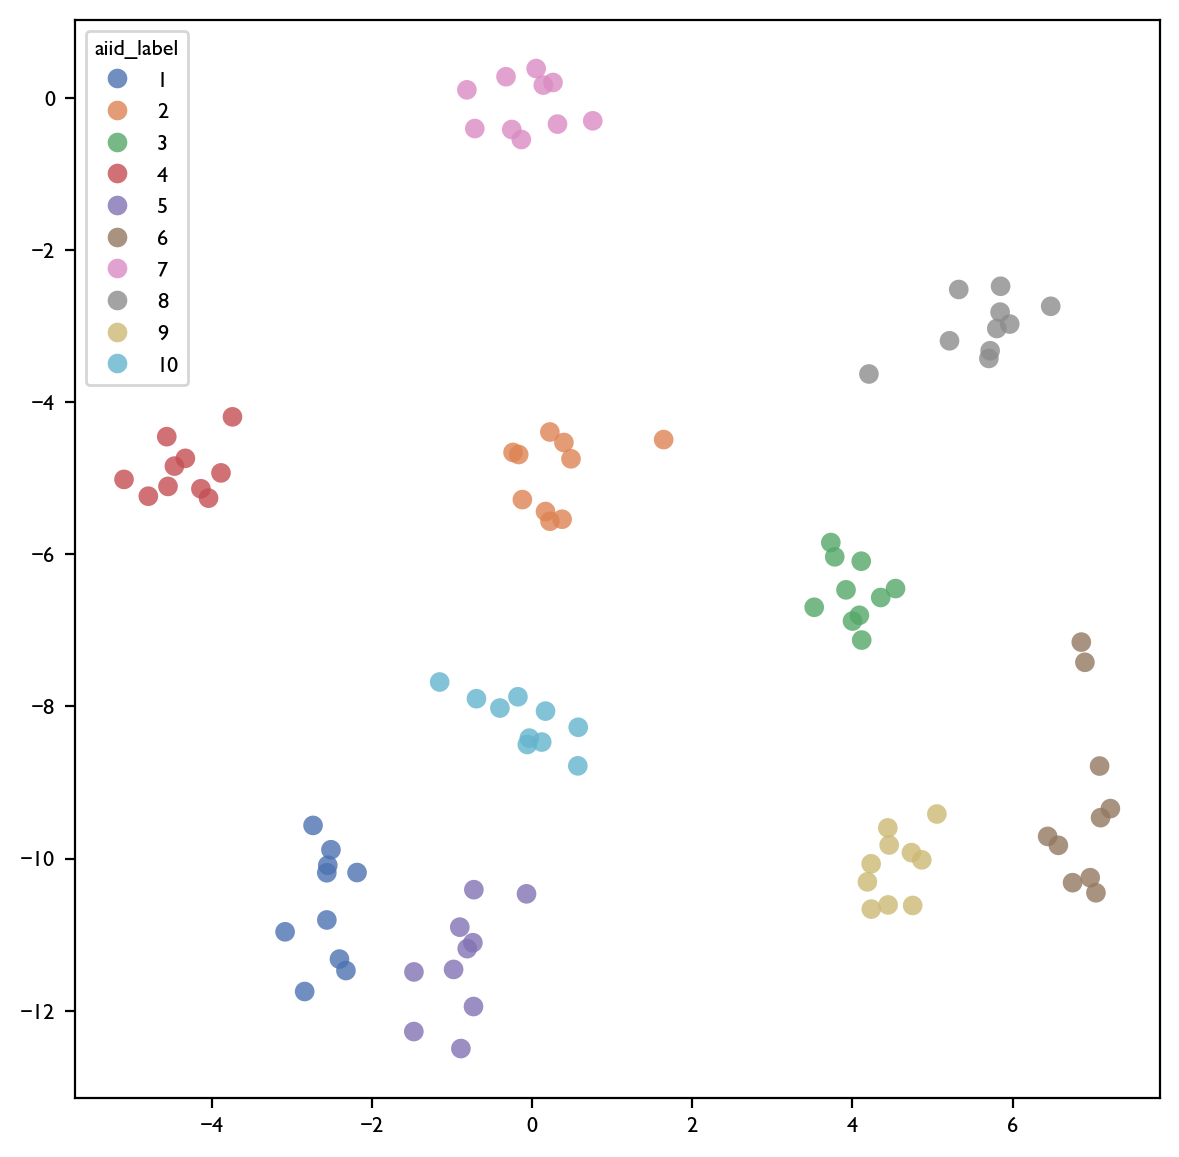

In [56]:
figsize(7,7)
sns.scatterplot(
    x=emb_2d[:, 0],
    y=emb_2d[:, 1],
    hue=audio_clip_table.aiid_label,
    palette=palette,
    s=50,
    alpha=0.8,
    edgecolor="none",
)

## Inspect 3 songs from each of 3 individuals

Individual ID: 1


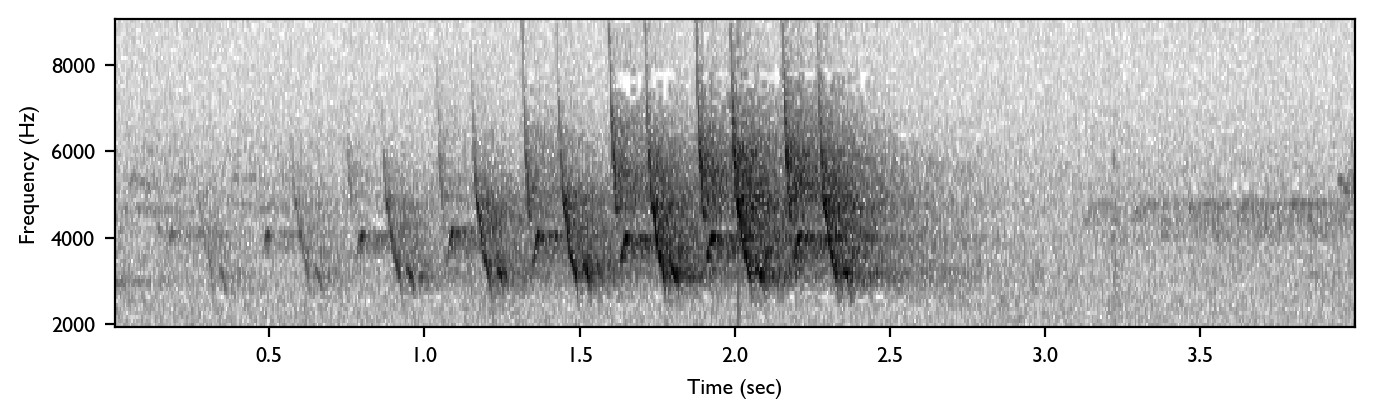

Individual ID: 1


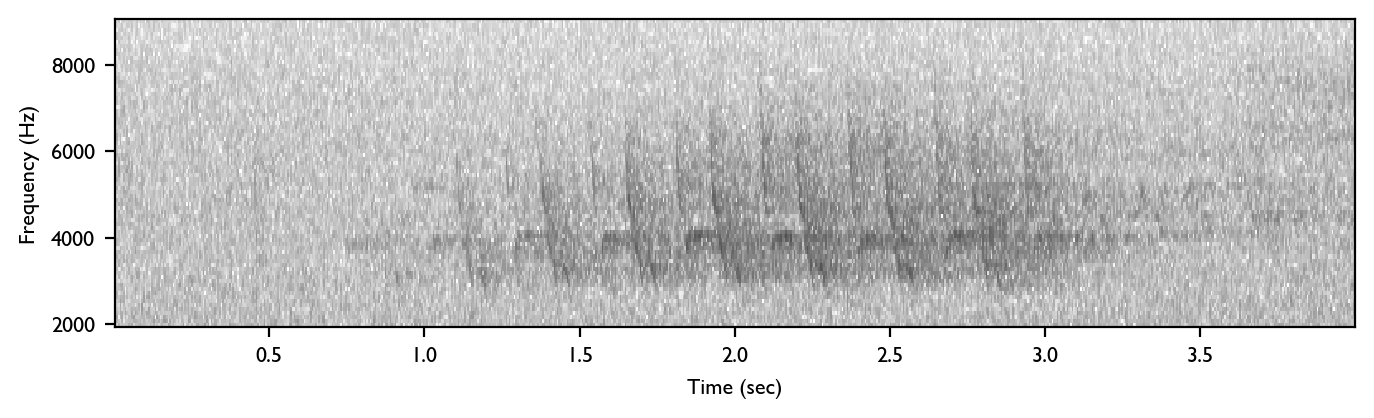

Individual ID: 1


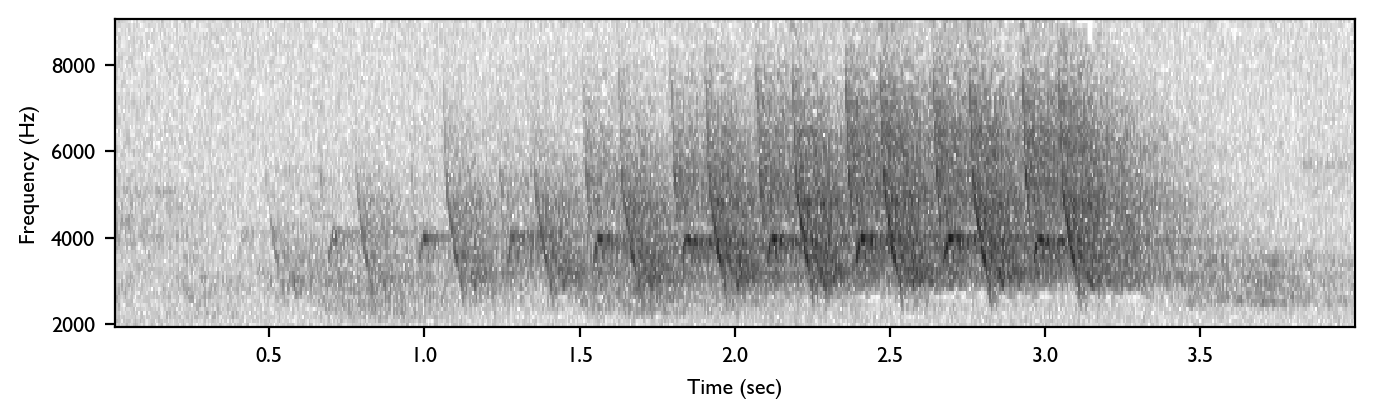

Individual ID: 2


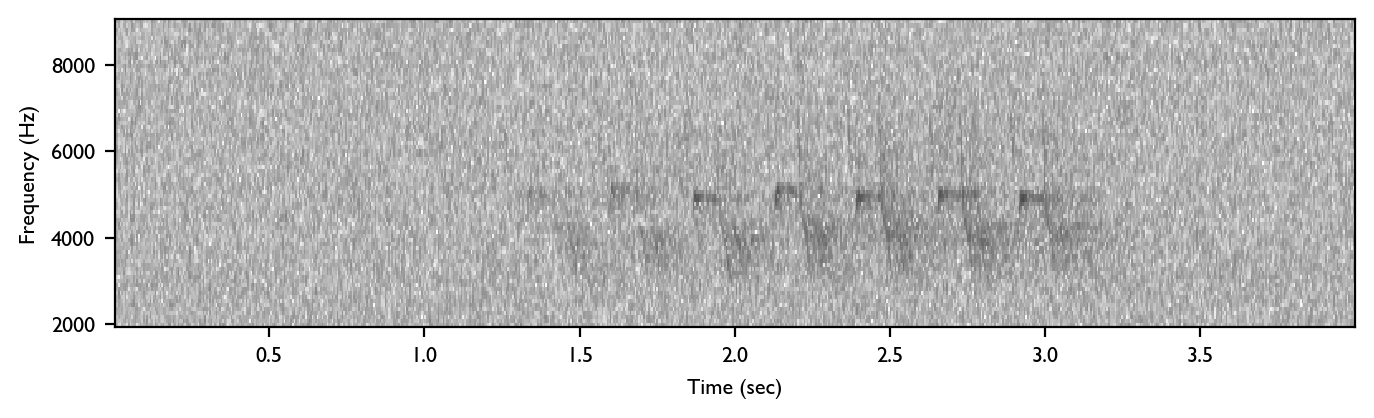

Individual ID: 2


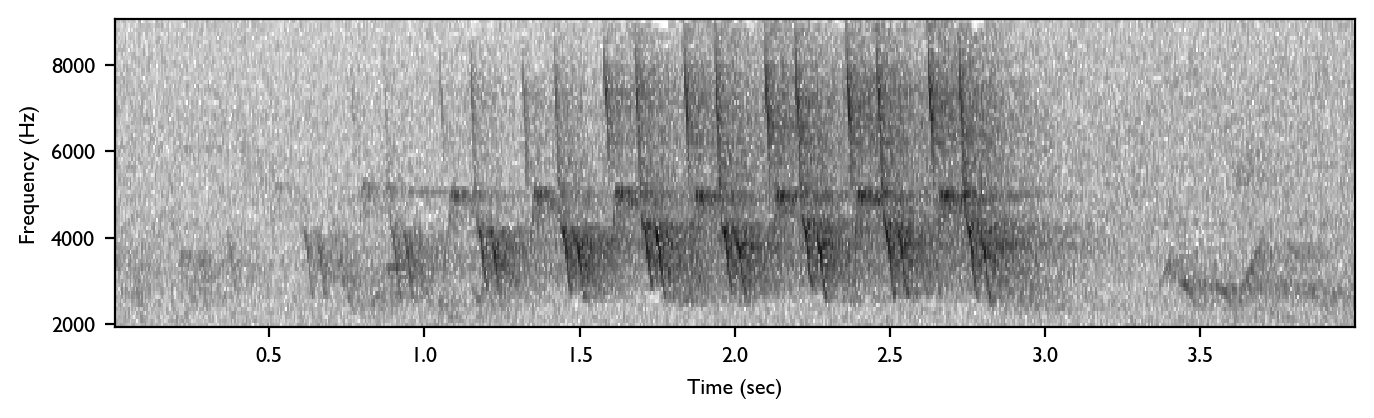

Individual ID: 2


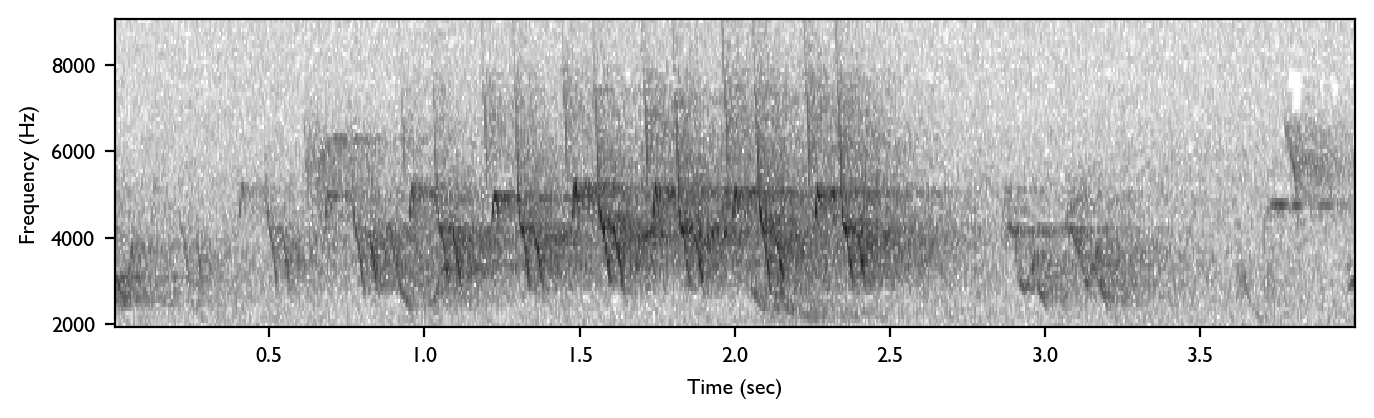

Individual ID: 3


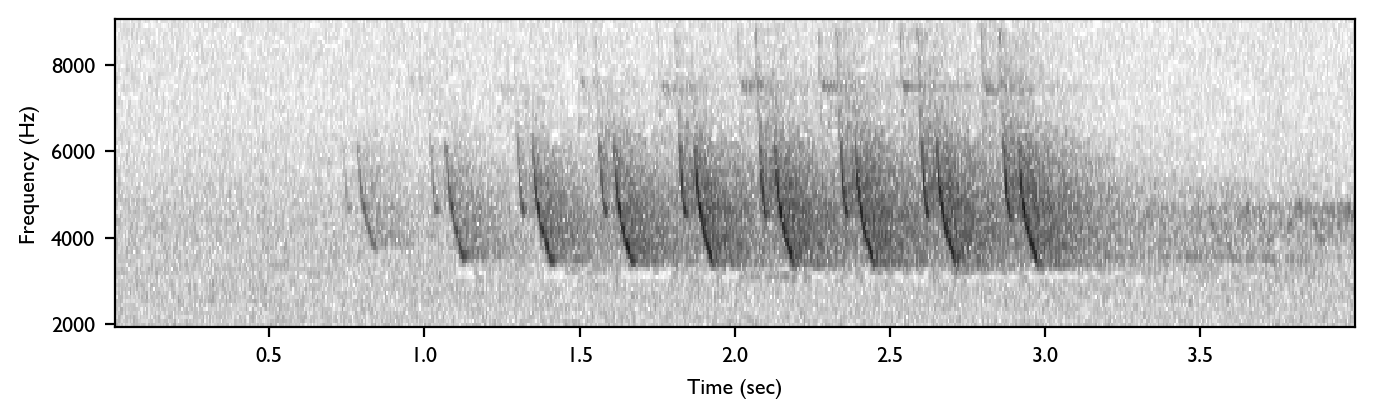

Individual ID: 3


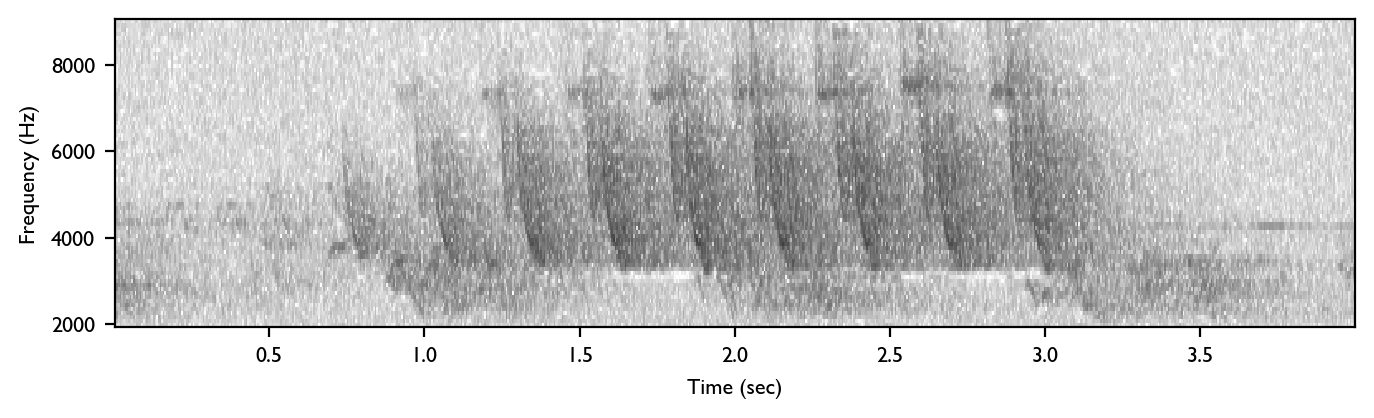

Individual ID: 3


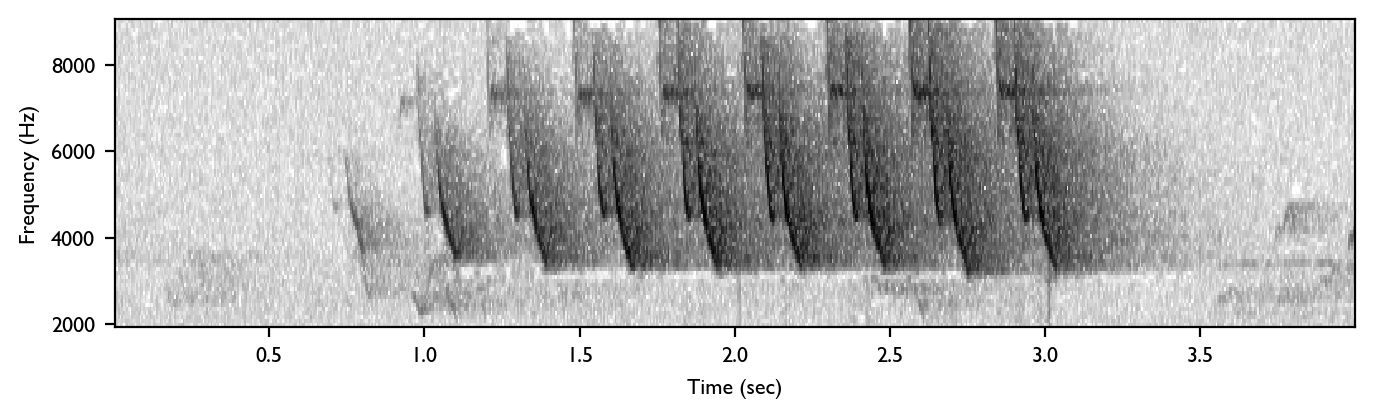

In [66]:
figsize(8,2)
from opensoundscape import Audio, Spectrogram

individuals = [1,2,3]
for indv in individuals:
    individual_clips = audio_clip_table[audio_clip_table.aiid_label==indv]
    for i in range(3):
        print(f"Individual ID: {individual_clips.iloc[i].aiid_label}")
        a=Audio.from_file(individual_clips.file.iloc[i]).trim(3,7)
        a.show_widget()
        Spectrogram.from_audio(a).bandpass(2000,9000).plot()